# Initialize perqueue

In [1]:
from perqueue.backend.handler import init_backend
from perqueue.backend.sqlitebackend import SQLiteBackend

init_backend(backend_type=SQLiteBackend._type, force=True)

# Run Workflow 

In [2]:
from perqueue import PersistentQueue
from perqueue.external.python_workflow_definition import write_PWD, read_PWD

wf, undef_scripts = read_PWD("workflow.json", write_scripts = True)
PWD_dict = write_PWD(wf, "test.json")

with PersistentQueue() as pq:
    pq.submit(wf)

Running job 1 locally.

# Visualize 

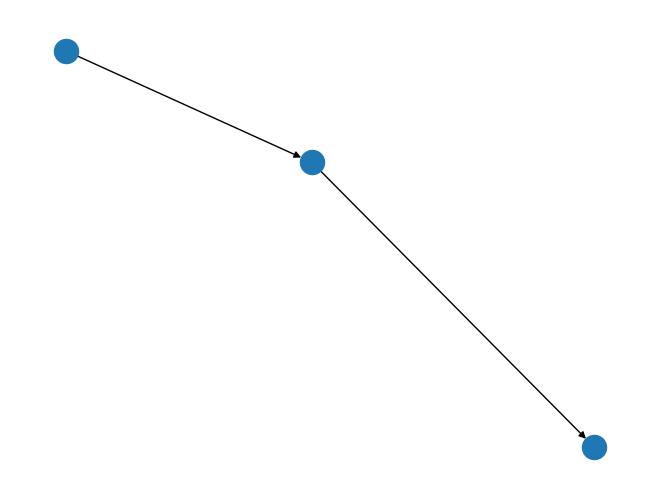

In [3]:
import networkx as nx

nx.draw(wf.dependencies)

# Debug 

In [4]:
!cat perqueue.local.*

Perqueue key:   1
Code:           /home/jovyan/workflow.py
User Arguments: {'x': 1, 'y': 2}
PQ Arguments:   {}
------------------------------------------------------------------------------

Running job 2 locally.
{1: {'x': 2, 'y': 0.5}}
Perqueue key:   2
Code:           /home/jovyan/workflow.py
User Arguments: {'y': 0.5, 'x': 2}
PQ Arguments:   {}
------------------------------------------------------------------------------

Running job 3 locally.
{2: {'x': 2.5}}
Perqueue key:   3
Code:           /home/jovyan/workflow.py
User Arguments: {'x': 2.5}
PQ Arguments:   {}
------------------------------------------------------------------------------

